# Task 3

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm

from tools.pcd_tools import downsample_voxel, pcd_from_path
from tools.plot_tools import plot_pcd, show_pcl, view_frames
from tools.analysis_tools import calc_error
from tools.ICP import ICP, rigid_transformation, calculate_centroid

In [3]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset tooling

In [4]:
class FrameDataset():
    def __init__(self, frames_dir: str, ground_truth_path: str):
        """
        Initialize the FrameDataset object.

        Args:
            frames_dir (str): The path to the frames directory.
            ground_truth_path (str): The path to the ground truth CSV file.
        """
        self.frames_dir = frames_dir
        self.ground_truth_path = ground_truth_path
        self.frames = self._load_frames()
        self.ground_truth = self._load_ground_truth()

    def _load_frames(self):
        frames = []
        for file in os.listdir(self.frames_dir):
            if file.endswith(".pcd"):
                frames.append(os.path.join(self.frames_dir, file))
        
        # sort frames by number, frames are named like this: frame_0.pcd
        frames.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
        return frames

    def _load_ground_truth(self):
        gts = pd.read_csv(self.ground_truth_path, skipinitialspace=True)
        return gts
    
    def __len__(self):
        return len(self.frames)
    
    def __getitem__(self, idx):
        """
        Get the frame, ground truth position and orientation for the given index.

        Args:
            idx (int): The index of the frame to get.

        Returns:
            pcd (open3d.geometry.PointCloud): The point cloud of the frame.
            gt_pos (numpy.ndarray): The ground truth position of the frame.
            gt_orientation (numpy.ndarray): The ground truth orientation of the frame.
        """
        frame = self.frames[idx]
        pcd = pcd_from_path(frame)

        ground_truth = self.ground_truth.iloc[idx]
        gt_pos = ground_truth[['x', 'y', 'z']].to_numpy()
        gt_orientation = ground_truth[['roll', 'pitch', 'yaw']].to_numpy()

        return pcd, gt_pos, gt_orientation

In [5]:
dataset = FrameDataset(FRAMES_DIR, GT_PATH)

print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


In [6]:
list_of_frames = [dataset[i][0] for i in range(len(dataset))]

view_frames(list_of_frames)

## Experiment: Align and evaluate 2 frames

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm

from tools.pcd_tools import downsample_voxel, pcd_from_path
from tools.plot_tools import plot_pcd, show_pcl, view_frames
from tools.analysis_tools import calc_error
from tools.ICP import ICP, rigid_transformation, calculate_centroid

# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

# Load the map
map_pcd = pcd_from_path(MAP_PATH)

# Load dataset
dataset = FrameDataset(FRAMES_DIR, GT_PATH)
print(f"Number of frames: {len(dataset)}")

# Define parameters
voxel_size = 0.25  # Voxel size for downsampling
max_frames = 1500   # Optional: limit number of frames to process
num_frames = min(len(dataset), max_frames)

# Lists to track results
gt_positions = []
estimated_positions = []
position_errors = []
computation_times = []

# Initialize transformation matrix (identity matrix)
# This will keep track of our current position and orientation
current_transformation = np.eye(4)

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
init_rot = Rotation.from_euler('xyz', init_orientation, degrees=False).as_matrix()

# Initialize with first ground truth position
init_transform = np.eye(4)
init_transform[:3, :3] = init_rot
init_transform[:3, 3] = init_pos
current_transformation = init_transform

# Process frames
pbar = tqdm(range(1, num_frames), desc="Processing frames", leave=True)

for i in pbar:
    # Get the current frame
    pcd, gt_pos, gt_orientation = dataset[i]
    
    # Store ground truth position
    gt_positions.append(gt_pos)
    
    # Voxelize the point clouds to reduce complexity
    start_time = time.time()
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
    map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)
    
    # Check if pcd_voxel is a numpy array and convert if needed
    if isinstance(pcd_voxel, np.ndarray):
        # If it's a numpy array, apply transformation using matrix multiplication
        # Assuming pcd_voxel is an Nx3 array of points
        # Create homogeneous coordinates (Nx4)
        homogeneous_points = np.hstack((pcd_voxel, np.ones((pcd_voxel.shape[0], 1))))
        # Apply transformation
        transformed_points = np.dot(homogeneous_points, current_transformation.T)
        # Convert back to 3D points
        pcd_voxel = transformed_points[:, :3]
    else:
        # If it's an Open3D point cloud, use the transform method
        pcd_voxel.transform(current_transformation)
    
    # Create ICP object
    icp = ICP(max_iterations=100, max_dist=5.0, tol=1e-6)
    
    # Run ICP to align current scan with map
    # The scan is already pre-transformed with our current estimate
    try:
        R, t, _, _, _ = icp.align(pcd_voxel, map_pcd_voxel)
        
        # Create transformation matrix from ICP result
        icp_transform = np.eye(4)
        icp_transform[:3, :3] = R
        # Fix the shape issue - reshape t to be 1D if it's a column vector
        if t.ndim > 1:  # If t is 2D (like shape (3,1))
            t = t.flatten()  # Convert to 1D array
        icp_transform[:3, 3] = t
    except Exception as e:
        print(f"ICP alignment failed: {e}")
        # If ICP fails, use identity transformation (no change)
        icp_transform = np.eye(4)
    
    # Update the current transformation with the ICP result
    current_transformation = np.matmul(icp_transform, current_transformation)
    
    # Extract current position from transformation matrix
    current_position = current_transformation[:3, 3]
    
    # Store estimated position
    estimated_positions.append(current_position)
    
    # Compute error
    position_error = np.linalg.norm(current_position - gt_pos)
    position_errors.append(position_error)
    
    # Compute execution time
    execution_time = time.time() - start_time
    computation_times.append(execution_time)
    
    # Update progress bar with current error
    pbar.set_postfix({"Position Error": f"{position_error:.2f}m", "Time": f"{execution_time:.2f}s"})

# Convert lists to numpy arrays
gt_positions = np.array(gt_positions)
estimated_positions = np.array(estimated_positions)
position_errors = np.array(position_errors)
computation_times = np.array(computation_times)

Number of frames: 1014


Processing frames:   0%|          | 0/1013 [00:00<?, ?it/s]

In [39]:
def calculate_lateral_errors(gt_positions, estimated_positions):
    """
    Calculate lateral errors between ground truth and estimated positions.
    
    Lateral error is the perpendicular distance from the estimated position
    to the intended path (as defined by the ground truth trajectory).
    
    Args:
        gt_positions: Ground truth positions (numpy array of shape Nx3)
        estimated_positions: Estimated positions (numpy array of shape Nx3)
        
    Returns:
        lateral_errors: Array of lateral errors for each position
    """
    import numpy as np
    
    lateral_errors = []
    
    # For each point, calculate heading and lateral error
    for i in range(len(gt_positions)):
        # Calculate the heading vector
        if i < len(gt_positions) - 1:
            # Use the vector to the next point
            heading = gt_positions[i+1] - gt_positions[i]
        elif i > 0:
            # For the last point, use the vector from the previous point
            heading = gt_positions[i] - gt_positions[i-1]
        else:
            # If there's only one point, we can't calculate lateral error
            continue
            
        # Only use x and y components for 2D lateral error
        heading_xy = heading[:2]
        
        # Normalize the heading vector
        if np.linalg.norm(heading_xy) > 0:
            heading_xy = heading_xy / np.linalg.norm(heading_xy)
        else:
            continue
        
        # Calculate error vector (estimated - ground truth)
        error_vector = estimated_positions[i] - gt_positions[i]
        error_vector_xy = error_vector[:2]
        
        # Calculate the lateral component (perpendicular to heading)
        # For 2D vectors, perpendicular is [-y, x]
        perpendicular = np.array([-heading_xy[1], heading_xy[0]])
        
        # Project error onto perpendicular vector to get lateral error
        lateral_error = np.abs(np.dot(error_vector_xy, perpendicular))
        lateral_errors.append(lateral_error)
    
    return np.array(lateral_errors)

# Example usage in your main code:
lateral_errors = calculate_lateral_errors(gt_positions, estimated_positions)

Mean lateral error: 0.13 meters
Max lateral error: 1.14 meters
Mean computation time: 0.55 seconds


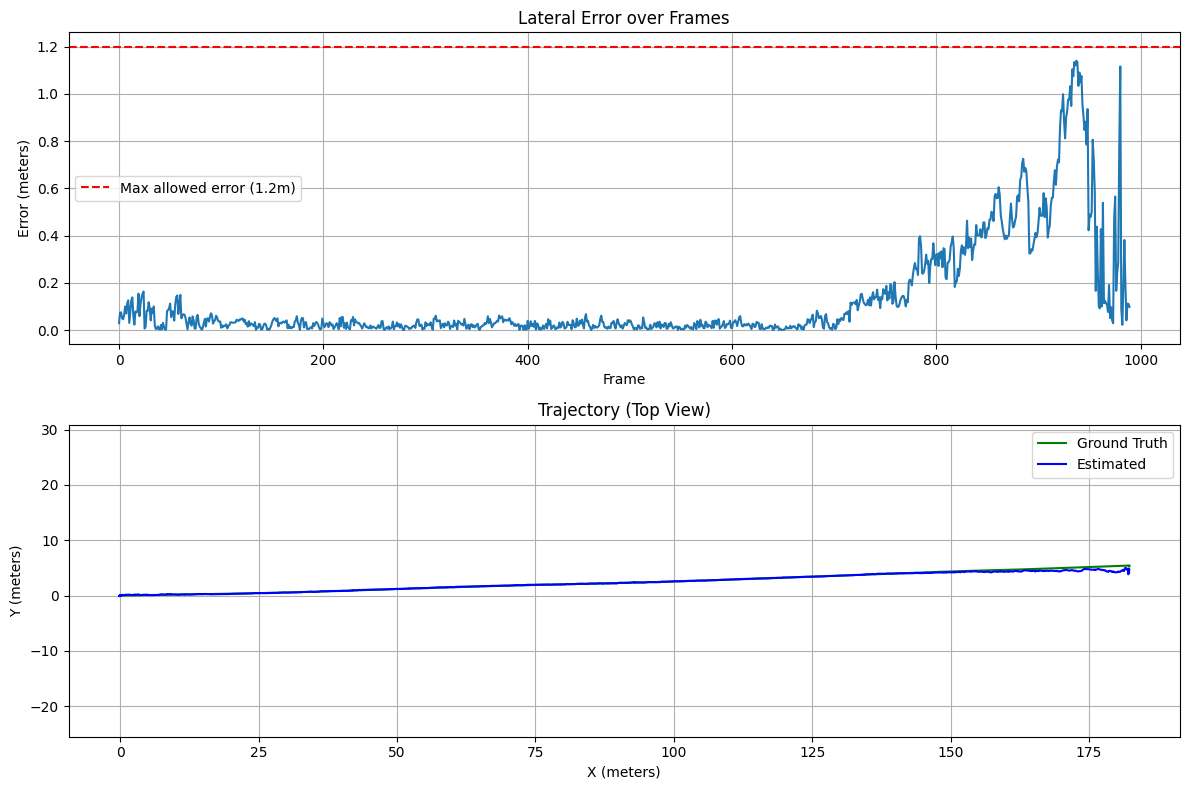

In [40]:
mean_error = np.mean(lateral_errors)
max_error = np.max(lateral_errors)
mean_time = np.mean(computation_times)

print(f"Mean lateral error: {mean_error:.2f} meters")
print(f"Max lateral error: {max_error:.2f} meters")
print(f"Mean computation time: {mean_time:.2f} seconds")

# Plot results
plt.figure(figsize=(12, 8))

# Plot lateral error over frames
plt.subplot(2, 1, 1)
plt.plot(lateral_errors)
plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')
plt.title("Lateral Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Error (meters)")
plt.legend()
plt.grid(True)

# Plot trajectory
plt.subplot(2, 1, 2)
plt.plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', label='Ground Truth')
plt.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'b-', label='Estimated')
plt.title("Trajectory (Top View)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()

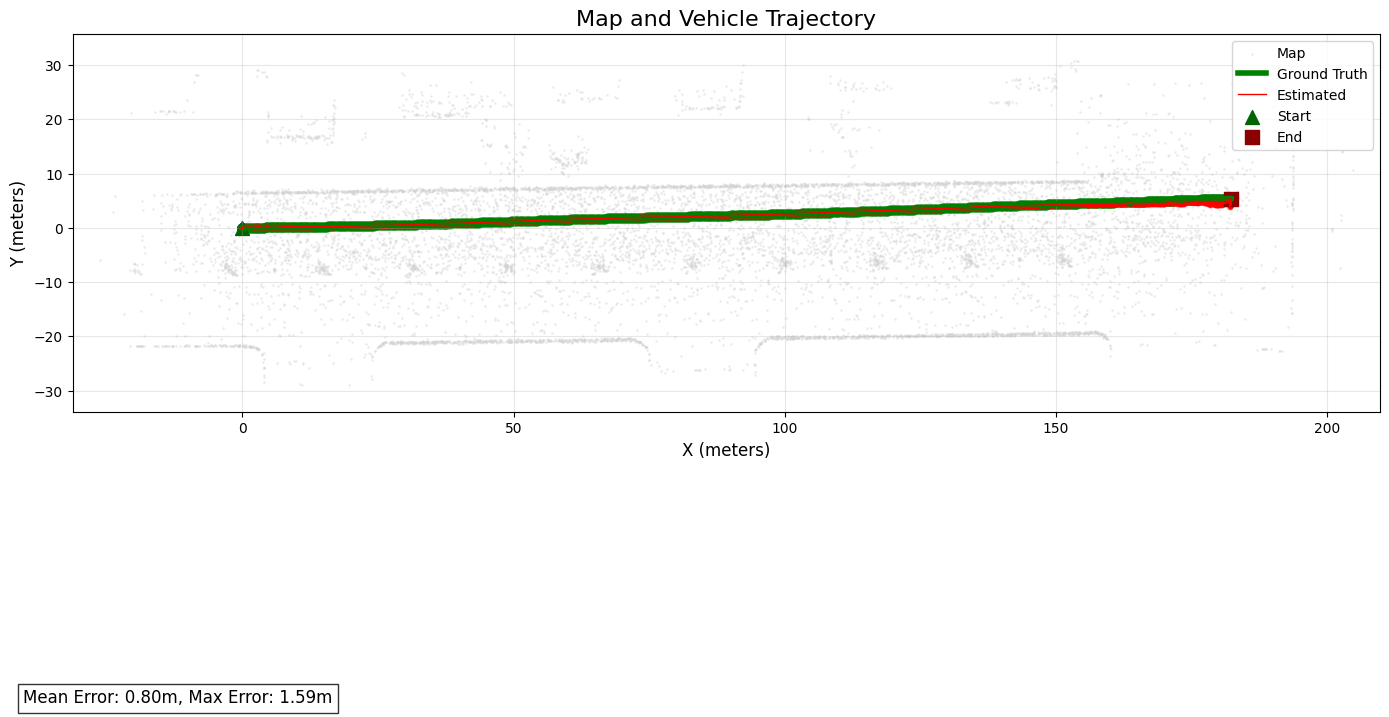

In [37]:
def plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions, save_path=None):
    """
    Plot the map point cloud, ground truth positions, and estimated positions in 2D.
    
    Args:
        map_pcd: The map point cloud (numpy array of shape Nx3)
        gt_positions: Ground truth positions (numpy array of shape Mx3)
        estimated_positions: Estimated positions (numpy array of shape Mx3)
        save_path: Optional path to save the figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure with adequate size
    plt.figure(figsize=(14, 10))
    
    # Plot map points (with low alpha to not overwhelm the plot)
    # Only use a subset of points to make the plot more efficient
    if len(map_pcd) > 10000:
        # Randomly sample points to reduce density
        indices = np.random.choice(len(map_pcd), 10000, replace=False)
        map_subset = map_pcd[indices]
    else:
        map_subset = map_pcd
    
    # Plot the map as a scatter plot (top-down view, so X and Y coordinates)
    plt.scatter(map_subset[:, 0], map_subset[:, 1], c='lightgray', s=1, alpha=0.3, label='Map')
    
    # Plot ground truth trajectory
    plt.plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', linewidth=4, label='Ground Truth')
    plt.scatter(gt_positions[:, 0], gt_positions[:, 1], c='green', s=40, alpha=0.6)
    
    # Plot estimated trajectory
    plt.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'r-', linewidth=1, label='Estimated')
    plt.scatter(estimated_positions[:, 0], estimated_positions[:, 1], c='r', s=10, alpha=0.6)
    
    # Highlight start and end points
    plt.scatter(gt_positions[0, 0], gt_positions[0, 1], c='darkgreen', s=100, marker='^', label='Start')
    plt.scatter(gt_positions[-1, 0], gt_positions[-1, 1], c='darkred', s=100, marker='s', label='End')
    
    # Draw lines connecting ground truth and estimated positions to visualize errors
    for i in range(len(gt_positions)):
        plt.plot([gt_positions[i, 0], estimated_positions[i, 0]], 
                 [gt_positions[i, 1], estimated_positions[i, 1]], 
                 'r-', alpha=0.2, linewidth=0.5)
    
    # Calculate the range of the map to set proper aspect ratio
    x_min, x_max = np.min(map_subset[:, 0]), np.max(map_subset[:, 0])
    y_min, y_max = np.min(map_subset[:, 1]), np.max(map_subset[:, 1])
    
    # Add some padding around the map
    padding = 5  # meters
    plt.xlim(x_min - padding, x_max + padding)
    plt.ylim(y_min - padding, y_max + padding)
    
    # Set equal aspect ratio
    plt.gca().set_aspect('equal')
    
    # Add title, labels, legend
    plt.title('Map and Vehicle Trajectory', fontsize=16)
    plt.xlabel('X (meters)', fontsize=12)
    plt.ylabel('Y (meters)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Calculate and display statistics
    errors = np.linalg.norm(gt_positions - estimated_positions, axis=1)
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    
    plt.figtext(0.02, 0.02, f'Mean Error: {mean_error:.2f}m, Max Error: {max_error:.2f}m', 
                fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    # Show the plot
    plt.show()

# Example usage:
plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)